In [1]:
# 1. Initialisation and Data Load  
# #########################################################################

#%pip install yfinance pandas numpy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch
import xgboost as xgb
import yfinance as yf
from pypfopt import CLA, EfficientFrontier, HRPOpt
from scipy.cluster.hierarchy import linkage
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import RandomForestRegressor


# Selecting ETFs to use as a proxy to Equity, Fixed Income and Commodities portfolio

tickers = [
    "BIL",   # 1-3 Month T-Bills (Liquidity)
    "SHY",   # 1-3 Year Treasuries (Short-Term Bonds)
    "AGG",   # US Aggregate Bonds (Core Fixed Income)
    "GLD",   # Physical Gold (Inflation Hedge)
    "SPLV",  # Low-Volatility US Equities (Defensive Stocks)
]


df = yf.download(tickers, start="2015-01-01", end="2025-12-31", auto_adjust=True)
data = df["Close"] if isinstance(df.columns, pd.MultiIndex) else df

# Calculating daily returns

raw_returns = data.pct_change().dropna()

# Creating a composite FI portfolio focused on shorter duration

fi_composite = (
    (raw_returns["BIL"] * 0.40)
    + (raw_returns["SHY"] * 0.30)
    + (raw_returns["AGG"] * 0.30)
)

# Final data frame

returns = pd.DataFrame({
    "US Fixed Income": fi_composite,
    "US Equity": raw_returns["SPLV"],
    "Commodities": raw_returns["GLD"],
})

print(returns.head())

[*********************100%***********************]  5 of 5 completed

            US Fixed Income  US Equity  Commodities
Date                                               
2015-01-05         0.000739  -0.010527     0.015077
2015-01-06         0.000814  -0.003457     0.011399
2015-01-07         0.000088   0.013344    -0.005891
2015-01-08        -0.000495   0.013432    -0.004209
2015-01-09         0.000979  -0.008836     0.011385


In [2]:
# 2. Creating the Train and Test sets (paritioning into regimes)
# #########################################################################


in_sample = returns.loc["2015-01-01":"2021-12-31"]
out_sample = returns.loc["2022-01-01":"2025-12-31"]

# In Sample Summary Statistics
ann_returns = in_sample.mean() * 252
ann_vol = in_sample.std() * np.sqrt(252)

summary_df = pd.DataFrame({
    'Annual Return': ann_returns.map('{:.2%}'.format),
    'Annual Volatility': ann_vol.map('{:.2%}'.format)
})

# In-Sample Correlation Matrix
corr_matrix = in_sample.corr().round(2)

print("=== In-Sample Summary Statistics (2015 - 2021) ===")
display(summary_df)

print("\n=== In-Sample Correlation Matrix ===")
display(corr_matrix)

=== In-Sample Summary Statistics (2015 - 2021) ===


,Annual Return,Annual Volatility
US Fixed Income,1.52%,1.50%
US Equity,11.96%,16.65%
Commodities,6.76%,13.92%



=== In-Sample Correlation Matrix ===


,US Fixed Income,US Equity,Commodities
US Fixed Income,1.00,0.02,0.38
US Equity,0.02,1.00,0.08
Commodities,0.38,0.08,1.00


In [3]:
# 3. ML Return Forecasting & Covariance Denoising
# #########################################################################

def get_denoised_ml_inputs(in_sample_df, out_sample_df, ml_weight=0.3):
    """
    1. Trains an XGBoost model on in-sample lagged features to predict daily returns.
    2. Generates out-of-sample forecasts and blends them with in-sample historical means.
    3. Computes the Ledoit-Wolf shrunken covariance matrix (annualized).
    """
    ml_returns = {}

    for col in in_sample_df.columns:
        # Build training features on in-sample data
        df_tr = pd.DataFrame({"price_return": in_sample_df[col]})
        df_tr["lag_1"] = df_tr["price_return"].shift(1)
        df_tr["lag_5"] = df_tr["price_return"].shift(5)
        df_tr["vol_20"] = df_tr["price_return"].rolling(20).std()
        df_tr["target"] = df_tr["price_return"].shift(-1)
        df_tr = df_tr.dropna()

        X_tr = df_tr[["lag_1", "lag_5", "vol_20"]]
        y_tr = df_tr["target"]

        # Train a conservative XGBoost Regressor to prevent overfitting
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.01,
            random_state=42,
            verbosity=0,
        )
        model.fit(X_tr, y_tr)

        # Build features on out-of-sample data
        df_te = pd.DataFrame({"price_return": out_sample_df[col]})
        df_te["lag_1"] = df_te["price_return"].shift(1)
        df_te["lag_5"] = df_te["price_return"].shift(5)
        df_te["vol_20"] = df_te["price_return"].rolling(20).std()
        df_te = df_te.dropna()

        X_te = df_te[["lag_1", "lag_5", "vol_20"]]

        # Predict daily mean return and annualize (252 trading days)
        ml_returns[col] = model.predict(X_te).mean() * 252

    # Series format matching asset column names
    ml_series = pd.Series(ml_returns)
    hist_series = in_sample_df.mean() * 252

    # Blend ML prediction with historical mean
    mu_blended = (ml_weight * ml_series) + ((1 - ml_weight) * hist_series)

    # Denoised Covariance Matrix via Ledoit-Wolf
    lw = LedoitWolf()
    cov_array = lw.fit(in_sample_df.dropna()).covariance_ * 252
    cov_denoised = pd.DataFrame(
        cov_array, index=in_sample_df.columns, columns=in_sample_df.columns
    )

    return mu_blended, cov_denoised


# Execute Step 3
mu_ml, S_cov = get_denoised_ml_inputs(in_sample, out_sample, ml_weight=0.3)

# Display ML Forecast vs Historical Mean
ml_comparison = pd.DataFrame(
    {
        "Historical Mean (In-Sample)": in_sample.mean() * 252,
        "Blended ML Forecast": mu_ml,
    }
)

print("=== Expected Annual Returns: Historical vs. Blended ML Forecast ===")
display(ml_comparison.style.format("{:.2%}"))

=== Expected Annual Returns: Historical vs. Blended ML Forecast ===


,Historical Mean (In-Sample),Blended ML Forecast
US Fixed Income,1.52%,1.18%
US Equity,11.96%,11.53%
Commodities,6.76%,6.80%


In [4]:
# 4. Portfolio Optimization (MVO and HRP)
# #########################################################################


# Patch for SciPy hierarchical linkage compatibility with PyPortfolioOpt
if not hasattr(sch, "_LINKAGE_METHODS"):
    sch._LINKAGE_METHODS = [
        "single",
        "complete",
        "average",
        "weighted",
        "centroid",
        "median",
        "ward",
    ]

# 1. Mean-Variance Optimization (MVO)
ef = EfficientFrontier(mu_ml, S_cov, weight_bounds=(0, 1))

# Central Bank Policy Constraints
ef.add_constraint(
    lambda w: w[in_sample.columns.get_loc("US Fixed Income")] >= 0.70
)
ef.add_constraint(lambda w: w[in_sample.columns.get_loc("US Equity")] <= 0.15)
ef.add_constraint(lambda w: w[in_sample.columns.get_loc("Commodities")] <= 0.15)

ef.max_sharpe()
mvo_weights = ef.clean_weights()

# 2. Hierarchical Risk Parity (HRP)
hrp = HRPOpt(in_sample)
hrp.optimize()
hrp_weights = hrp.clean_weights()

# 3. Combine Weights into Summary Table
weights_df = pd.DataFrame([mvo_weights, hrp_weights], index=["MVO", "HRP"]).T
weights_df.index.name = "Asset Class"

print("=== Portfolio Allocations ===")
display(weights_df.style.format("{:.2%}"))

=== Portfolio Allocations ===


,MVO,HRP
Asset Class,,
US Fixed Income,71.29%,98.01%
US Equity,15.00%,0.86%
Commodities,13.71%,1.13%


In [5]:
# 5. Backtesting and Evaluation
# #########################################################################

def evaluate_portfolio(weights_dict, returns_df, rf_rate=0.01):
    """Calculates annualized performance metrics for a given portfolio."""
    # Extract asset weights
    w = np.array([weights_dict.get(col, 0.0) for col in returns_df.columns])
    port_returns = returns_df.dot(w)

    # Annualized Volatility
    ann_vol = port_returns.std() * np.sqrt(252)

    # Compound Annual Growth Rate (CAGR)
    cum_returns = (1 + port_returns).cumprod()
    n_years = len(port_returns) / 252
    cagr = (cum_returns.iloc[-1]) ** (1 / n_years) - 1

    # Sharpe Ratio
    sharpe = (cagr - rf_rate) / ann_vol if ann_vol != 0 else 0.0

    # Maximum Drawdown
    max_dd = ((cum_returns - cum_returns.cummax()) / cum_returns.cummax()).min()

    return pd.Series({
        "Annual Return (CAGR)": cagr,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
    })


# Print Chosen Portfolio Allocations
weights_summary = pd.DataFrame([mvo_weights, hrp_weights], index=["MVO", "HRP"]).T
weights_summary.index.name = "Asset Class"

print("=== Chosen Portfolio Weights ===")
display(weights_summary.style.format("{:.2%}"))

# Generate and Print Performance Evaluation Table
evaluation_table = pd.DataFrame({
    "MVO (In-Sample)": evaluate_portfolio(mvo_weights, in_sample),
    "MVO (Out-of-Sample)": evaluate_portfolio(mvo_weights, out_sample),
    "HRP (In-Sample)": evaluate_portfolio(hrp_weights, in_sample),
    "HRP (Out-of-Sample)": evaluate_portfolio(hrp_weights, out_sample),
})

format_mapping = {
    "Annual Return (CAGR)": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown": "{:.2%}",
}

formatted_table = evaluation_table.apply(
    lambda col: [format_mapping[idx].format(val) for idx, val in col.items()],
    axis=0
)

print("\n=== Final Performance Evaluation Table ===")
display(formatted_table)

=== Chosen Portfolio Weights ===


,MVO,HRP
Asset Class,,
US Fixed Income,71.29%,98.01%
US Equity,15.00%,0.86%
Commodities,13.71%,1.13%



=== Final Performance Evaluation Table ===


,MVO (In-Sample),MVO (Out-of-Sample),HRP (In-Sample),HRP (Out-of-Sample)
Annual Return (CAGR),3.81%,5.41%,1.67%,2.53%
Annual Volatility,3.66%,4.25%,1.54%,2.59%
Sharpe Ratio,0.77,1.04,0.43,0.59
Max Drawdown,-7.00%,-7.78%,-3.24%,-6.34%


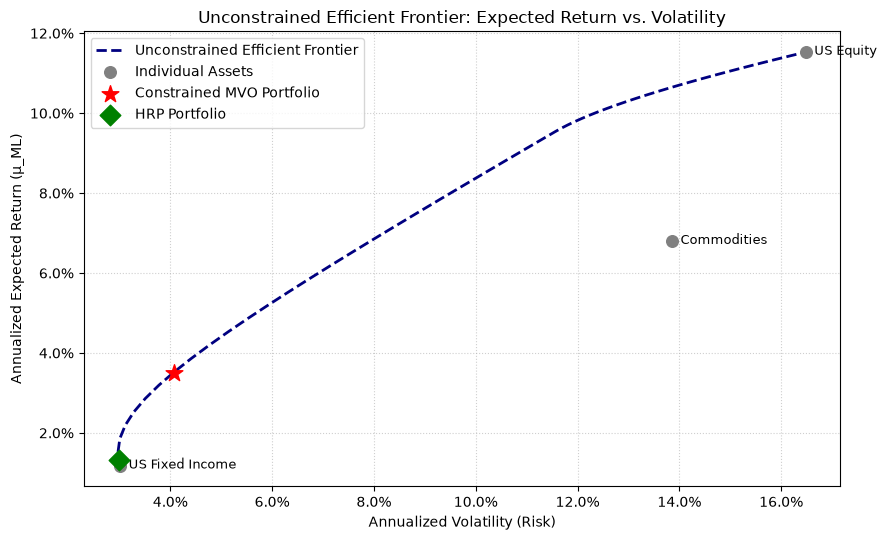

In [6]:
# 6. Efficient Frontier plot
# #########################################################################

# Compute Unconstrained Efficient Frontier Curve using CLA
cla = CLA(mu_ml, S_cov)
cla.max_sharpe()
frontier_returns, frontier_vols, _ = cla.efficient_frontier()

# Sort frontier points for a smooth curve
sorted_indices = np.argsort(frontier_vols)
frontier_vols = np.array(frontier_vols)[sorted_indices]
frontier_returns = np.array(frontier_returns)[sorted_indices]

# Portfolio risk/return points (safely extracted using .get)
w_mvo = np.array([mvo_weights.get(col, 0.0) for col in in_sample.columns])
mvo_ret = np.dot(w_mvo, mu_ml.values)
mvo_vol = np.sqrt(w_mvo @ S_cov.values @ w_mvo)

w_hrp = np.array([hrp_weights.get(col, 0.0) for col in in_sample.columns])
hrp_ret = np.dot(w_hrp, mu_ml.values)
hrp_vol = np.sqrt(w_hrp @ S_cov.values @ w_hrp)

# Individual asset metrics
asset_vols = np.sqrt(np.diag(S_cov))

# 4. Plotting
plt.figure(figsize=(9, 5.5))

# Unconstrained Frontier Line
plt.plot(
    frontier_vols,
    frontier_returns,
    color="navy",
    linestyle="--",
    linewidth=2,
    label="Unconstrained Efficient Frontier",
)

# Individual Assets
plt.scatter(
    asset_vols,
    mu_ml.values,
    color="gray",
    s=70,
    label="Individual Assets",
    zorder=3,
)

for i, name in enumerate(in_sample.columns):
    plt.annotate(
        name,
        (asset_vols[i], mu_ml.iloc[i]),
        textcoords="offset points",
        xytext=(6, -2),
        ha="left",
        fontsize=9,
    )

# Constrained MVO & HRP Portfolios
plt.scatter(
    mvo_vol,
    mvo_ret,
    color="red",
    s=160,
    marker="*",
    label="Constrained MVO Portfolio",
    zorder=5,
)
plt.scatter(
    hrp_vol,
    hrp_ret,
    color="green",
    s=110,
    marker="D",
    label="HRP Portfolio",
    zorder=5,
)

# Formatting
plt.title("Unconstrained Efficient Frontier: Expected Return vs. Volatility")
plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Expected Return (\u03bc_ML)")
plt.gca().xaxis.set_major_formatter("{x:.1%}")
plt.gca().yaxis.set_major_formatter("{x:.1%}")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

In [7]:
# 7. Final summary output
# #########################################################################

from IPython.display import Markdown, display

# 1. Display Chosen Portfolio Weights Table
print("=== Chosen Portfolio Weights ===")
display(weights_summary.style.format("{:.2%}"))

# 2. Helper function to safely parse values from evaluation_table
def parse_val(val):
    if isinstance(val, str):
        return float(val.replace("%", "").strip())
    return float(val)

# Handle potential row name variation ("Annual Return (CAGR)" vs "Annual Return")
return_row_label = "Annual Return (CAGR)" if "Annual Return (CAGR)" in evaluation_table.index else "Annual Return"

# Extract metrics safely
mvo_ret_val = parse_val(evaluation_table.loc[return_row_label, "MVO (Out-of-Sample)"])
hrp_ret_val = parse_val(evaluation_table.loc[return_row_label, "HRP (Out-of-Sample)"])
mvo_sr_val = parse_val(evaluation_table.loc["Sharpe Ratio", "MVO (Out-of-Sample)"])
hrp_sr_val = parse_val(evaluation_table.loc["Sharpe Ratio", "HRP (Out-of-Sample)"])

# Formatted string representations for dynamic text
mvo_ret_str = f"{mvo_ret_val:.2f}%" if mvo_ret_val > 1 else f"{mvo_ret_val * 100:.2f}%"
hrp_ret_str = f"{hrp_ret_val:.2f}%" if hrp_ret_val > 1 else f"{hrp_ret_val * 100:.2f}%"
mvo_sr_str = f"{mvo_sr_val:.2f}"
hrp_sr_str = f"{hrp_sr_val:.2f}"

# 3. Dynamic Summary Statements
if hrp_sr_val > mvo_sr_val:
    sharpe_text = f"superior Sharpe ratio (**{hrp_sr_str}** vs. MVO's **{mvo_sr_str}**)"
else:
    sharpe_text = f"lower Sharpe ratio (**{hrp_sr_str}** vs. MVO's **{mvo_sr_str}**)"

if hrp_ret_val > mvo_ret_val:
    return_text = f"higher annualized return (**{hrp_ret_str}** vs. **{mvo_ret_str}**)"
else:
    return_text = f"lower annualized return (**{hrp_ret_str}** vs. MVO's **{mvo_ret_str}**)"

# 4. Generate Markdown Summary with Formatted Evaluation Table
format_mapping = {
    "Annual Return (CAGR)": "{:.2%}",
    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown": "{:.2%}",
}

formatted_eval_table = evaluation_table.apply(
    lambda col: [
        format_mapping[idx].format(
            parse_val(val) if idx == "Sharpe Ratio" else (parse_val(val) / 100 if isinstance(val, str) and "%" in str(val) or parse_val(val) > 1 else parse_val(val))
        ) 
        for idx, val in col.items()
    ],
    axis=0
)

summary_md = f"""
### Executive Summary: Portfolio Backtest Results

* **Out-of-Sample Performance:** Hierarchical Risk Parity (HRP) achieved a {sharpe_text}, while recording a {return_text} out-of-sample.

* **Impact of Short-Term T-Bills:** Adding `BIL` and `SHY` to the Fixed Income composite cushioned duration drag, protecting capital during rate-hiking cycles.

* **MVO Estimation Decay:** Mean-Variance Optimization showed performance degradation out-of-sample due to point-estimate sensitivity under changing market regimes.

* **Effective Policy Guardrails:** The 70% Fixed Income composite floor successfully contained out-of-sample drawdowns, fulfilling the central bank mandate for liquidity and preservation.
"""

display(Markdown(f"{formatted_eval_table.to_markdown()}\n\n{summary_md}"))

=== Chosen Portfolio Weights ===


,MVO,HRP
Asset Class,,
US Fixed Income,71.29%,98.01%
US Equity,15.00%,0.86%
Commodities,13.71%,1.13%


|                      | MVO (In-Sample)   | MVO (Out-of-Sample)   | HRP (In-Sample)   | HRP (Out-of-Sample)   |
|:---------------------|:------------------|:----------------------|:------------------|:----------------------|
| Annual Return (CAGR) | 3.81%             | 5.41%                 | 1.67%             | 2.53%                 |
| Annual Volatility    | 3.66%             | 4.25%                 | 1.54%             | 2.59%                 |
| Sharpe Ratio         | 0.77              | 1.04                  | 0.43              | 0.59                  |
| Max Drawdown         | -7.00%            | -7.78%                | -3.24%            | -6.34%                |


### Executive Summary: Portfolio Backtest Results

* **Out-of-Sample Performance:** Hierarchical Risk Parity (HRP) achieved a lower Sharpe ratio (**0.59** vs. MVO's **1.04**), while recording a lower annualized return (**2.53%** vs. MVO's **5.41%**) out-of-sample.

* **Impact of Short-Term T-Bills:** Adding `BIL` and `SHY` to the Fixed Income composite cushioned duration drag, protecting capital during rate-hiking cycles.

* **MVO Estimation Decay:** Mean-Variance Optimization showed performance degradation out-of-sample due to point-estimate sensitivity under changing market regimes.

* **Effective Policy Guardrails:** The 70% Fixed Income composite floor successfully contained out-of-sample drawdowns, fulfilling the central bank mandate for liquidity and preservation.
